In [30]:
from pathlib import Path
import numpy as np
from MNIST.Encode_0to9 import encode_diagonal

ROOT = Path.cwd()

test_path = ROOT / "data" / "test_MNIST_10x10_binarize0.5.npy"
label_path = ROOT / "data" / "test_MNIST_labels.npy"

X_test = np.load(test_path)
X_test = X_test.reshape(X_test.shape[0], -1)
X_test = X_test.astype(int)
X_flip = 1 - X_test# 01反转，由于不反转时0的比例太多了，1的比例太少了。
x_test_bitstrings=np.array(["".join(map(str, row)) for row in X_flip], dtype=str)
Y_test = np.load(label_path)
y_test_encoded= np.array([encode_diagonal(label) for label in Y_test])#不压平，保持10x10的形状，方便后续处理。

print(f"Loaded: {test_path}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")

theta_path = ROOT / "data" / "estimate_theta1.npz"
if not theta_path.exists():
	raise FileNotFoundError(f"未找到参数文件: {theta_path}")
with np.load(theta_path) as data:
	theta_hat_matrix = data["theta_hat_matrix"]
theta_hat_matrix_flat = theta_hat_matrix.reshape(-1)
print(theta_hat_matrix)

Loaded: d:\研究生\研究生\Quantum Machine learning\code\MNIST\data\test_MNIST_10x10_binarize0.5.npy
X_test shape: (10000, 100), dtype: int32
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         1.3632016  0.97089415 0.06949781
  0.42620039 2.20933974 0.         0.        ]
 [0.         0.         0.16571071 0.13245332 0.84990714 0.59725536
  0.260815   0.90247918 0.25231242 0.        ]
 [3.14159265 0.         0.3435257  0.79359333 0.20948817 0.50623507
  0.63449267 0.74114517 0.49959266 1.23095942]
 [0.         1.64493831 0.46136229 0.85589022 0.78060568 1.03210938
  0.57860931 0.20540245 0.27447789 0.        ]
 [0.         0.         0.42234871 0.35440509 0.91135418 0.09532049
  0.         0.59297665 0.2407734  0.        ]
 [0.         0.2249239  0.58106622 0.42830763 0.58029867 0.57856302
  1.15474095 0.05495114 1.86749528 0.        ]
 [0.         0.         0.99080221 0.23280868 0.81926964 0.50949191
 

test_bitstring: 1111111111111111111111100011111111101111111100111111111001111111110111111110111111100111111111111111


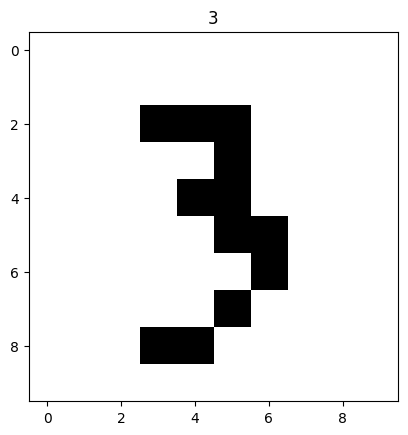

In [58]:
import random
n1=10
m=10
seed = 42
random.seed(seed)
n_number=1000#对于一个seed生成的n_number个y值
test_number=30
test_bitstring=x_test_bitstrings[test_number]
print(f"test_bitstring: {test_bitstring}")

import matplotlib.pyplot as plt

plt.imshow(X_flip.reshape(-1, 10, 10)[test_number], cmap='gray')
plt.title(Y_test[test_number])
plt.show()


In [35]:
from sampling.DQNN_generate_y import DQNN_generate_y
from tqdm import tqdm

y_generated =[]

for i in tqdm(range(n_number)):
    _,y= DQNN_generate_y(test_bitstring, n1, m, theta_hat_matrix_flat)
    y_generated.append(y)

y_generated=np.array(y_generated)

100%|██████████| 1000/1000 [02:04<00:00,  8.04it/s]


(1000, 100)
(100,)


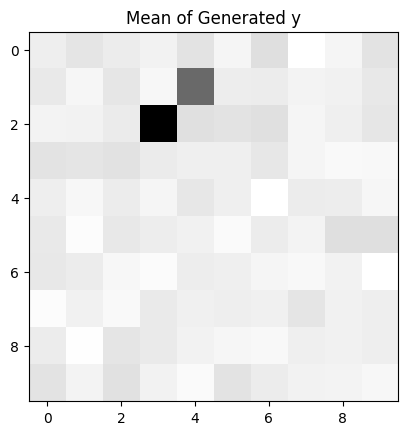

In [36]:
y_mean = y_generated.mean(axis=0)
y_mean_img=y_mean.reshape(10,10)
print(y_generated.shape)
print(y_mean.shape)
plt.imshow(y_mean_img, cmap='gray')
plt.title("Mean of Generated y")
plt.show()


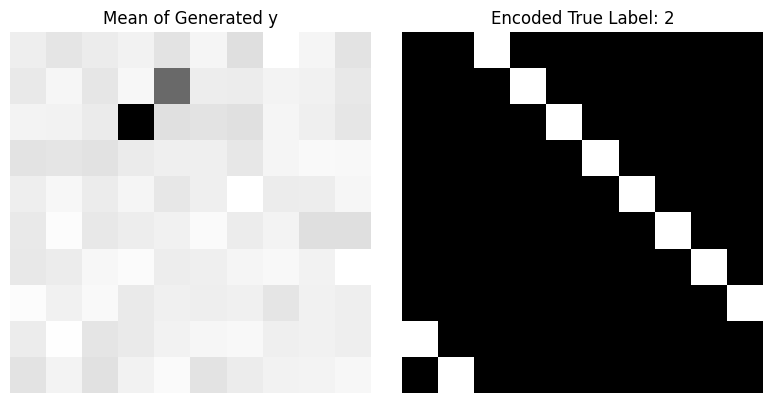

In [ ]:
output_dir = ROOT / "output_images" / "compare"
output_dir.mkdir(parents=True, exist_ok=True)

bitstring_text = str(test_bitstring)
filename = (
    f"mean_vs_encoded_"
    f"n1_{n1}_m_{m}_seed_{seed}_nNumber_{n_number}_"
    f"testIdx_{test_number}_trueLabel_{int(Y_test[test_number])}_"
    f"bitstring_{bitstring_text}.png"
)
save_path = output_dir / filename

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(y_mean_img, cmap='gray')
axes[0].set_title("Mean of Generated y")
axes[0].axis("off")

axes[1].imshow(y_test_encoded[test_number], cmap='gray')
axes[1].set_title(f"Encoded True Label: {Y_test[test_number]}")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")